# Smart Manufacturing Predictive Maintenance System
## Regression Track

### Objective

Predict machine **Tool Wear [min]** using machine operating characteristics.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA

from IPython.display import display

# Display settings
pd.set_option("display.max_columns", None)

# Visualization style
sns.set_theme(style="whitegrid")

# Reproducibility
RANDOM_STATE = 42

In [2]:
import os

print("Current working directory:")
print(os.getcwd())

Current working directory:
A:\Work\Projects\Smart Manufacturing Predictive Maintanance\notebooks\Other


In [3]:
file_path = r"../../Datasets/ai4i2020.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)
display(df.head())

Dataset loaded successfully!
Dataset shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## Controlled Missing-Value Experiment

The original AI4I 2020 dataset contains complete observations. To evaluate
the missing-value preprocessing pipeline under controlled conditions, a small
percentage of values was intentionally masked in selected predictor
variables.

The regression target, Tool wear [min], was kept complete so that valid
supervised learning labels are preserved.

The missing values are introduced only in predictor variables and are handled
using imputation inside the preprocessing pipeline.

In [4]:
# Introduce a small, controlled amount of missing data
# Only predictor variables are affected.
# The regression target remains complete.

missing_columns = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Type"
]

missing_rate = 0.02

rng = np.random.default_rng(RANDOM_STATE)

for column in missing_columns:
    n_missing = int(len(df) * missing_rate)

    missing_indices = rng.choice(
        df.index.to_numpy(),
        size=n_missing,
        replace=False
    )

    df.loc[missing_indices, column] = np.nan

print("Controlled missing values introduced successfully.")

print("\nMissing-value summary:")
display(df.isnull().sum())

print(
    "\nMissing Tool wear [min]:",
    df["Tool wear [min]"].isnull().sum()
)

Controlled missing values introduced successfully.

Missing-value summary:


UDI                          0
Product ID                   0
Type                       200
Air temperature [K]        200
Process temperature [K]    200
Rotational speed [rpm]     200
Torque [Nm]                200
Tool wear [min]              0
Machine failure              0
TWF                          0
HDF                          0
PWF                          0
OSF                          0
RNF                          0
dtype: int64


Missing Tool wear [min]: 0


## 1. Dataset Audit

Before preprocessing, the dataset is examined to understand its dimensions, variables, data types, missing values, duplicate records, and statistical characteristics.

In [5]:
# Column names

print("Column Names:\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Column Names:

1. UDI
2. Product ID
3. Type
4. Air temperature [K]
5. Process temperature [K]
6. Rotational speed [rpm]
7. Torque [Nm]
8. Tool wear [min]
9. Machine failure
10. TWF
11. HDF
12. PWF
13. OSF
14. RNF


In [6]:
# Data types

print("Data Types:\n")

display(df.dtypes)

Data Types:



UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]     float64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

In [7]:
# Missing-value analysis

missing_values = df.isnull().sum()

display(missing_values)

UDI                          0
Product ID                   0
Type                       200
Air temperature [K]        200
Process temperature [K]    200
Rotational speed [rpm]     200
Torque [Nm]                200
Tool wear [min]              0
Machine failure              0
TWF                          0
HDF                          0
PWF                          0
OSF                          0
RNF                          0
dtype: int64

In [8]:
# Total missing values

print("Total missing values:", df.isnull().sum().sum())

Total missing values: 1000


In [9]:
# Duplicate-row analysis

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [10]:
# Statistical summary

display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
UDI,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
Product ID,10000,10000,M14860,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type,9800,3,L,5881,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Air temperature [K],9800.0,NaN,NaN,NaN,300.000571,1.998959,295.3,298.3,300.1,301.5,304.5
Process temperature [K],9800.0,NaN,NaN,NaN,310.006714,1.483542,305.7,308.8,310.1,311.1,313.8
Rotational speed [rpm],9800.0,NaN,NaN,NaN,1538.787959,179.170502,1168.0,1423.0,1504.0,1612.0,2886.0
Torque [Nm],9800.0,NaN,NaN,NaN,39.988592,9.966884,3.8,33.2,40.1,46.8,76.6
Tool wear [min],10000.0,NaN,NaN,NaN,107.951,63.654147,0.0,53.0,108.0,162.0,253.0
Machine failure,10000.0,NaN,NaN,NaN,0.0339,0.180981,0.0,0.0,0.0,0.0,1.0
TWF,10000.0,NaN,NaN,NaN,0.0046,0.067671,0.0,0.0,0.0,0.0,1.0


## 2. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the distribution of variables, relationships between machine operating characteristics, and factors that may be associated with tool wear.

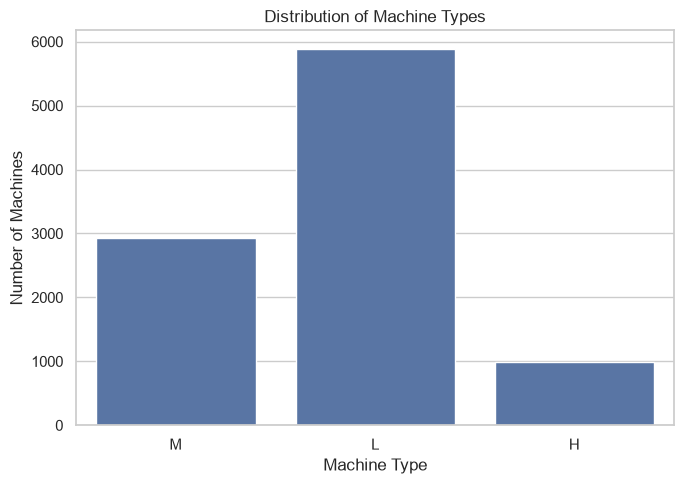

In [11]:
# Distribution of machine types

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Type")

plt.title("Distribution of Machine Types")
plt.xlabel("Machine Type")
plt.ylabel("Number of Machines")

plt.tight_layout()
plt.show()

### Observation

The dataset contains three machine/product types: L, M, and H. Type L represents the largest group of observations, while Type H represents the smallest group.

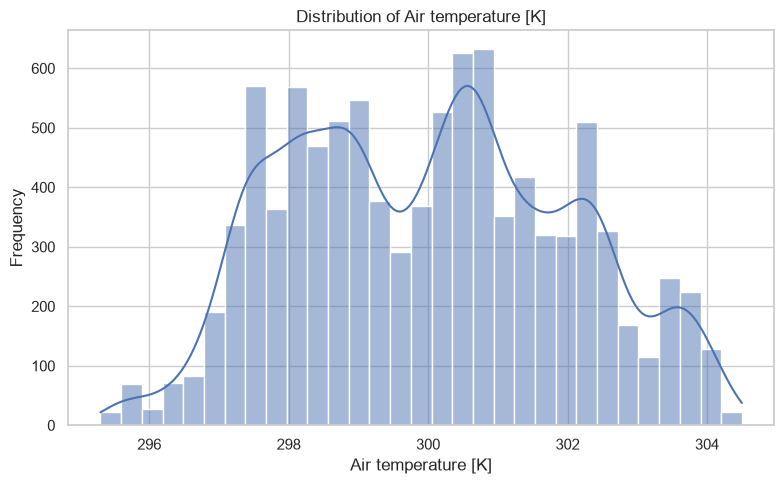

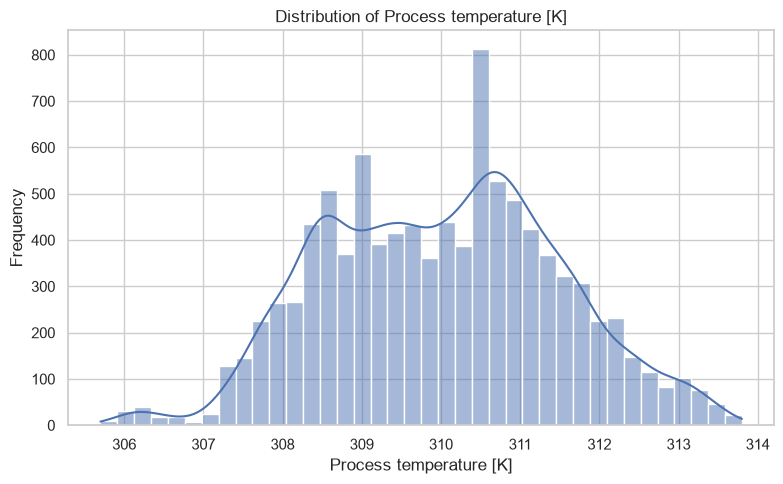

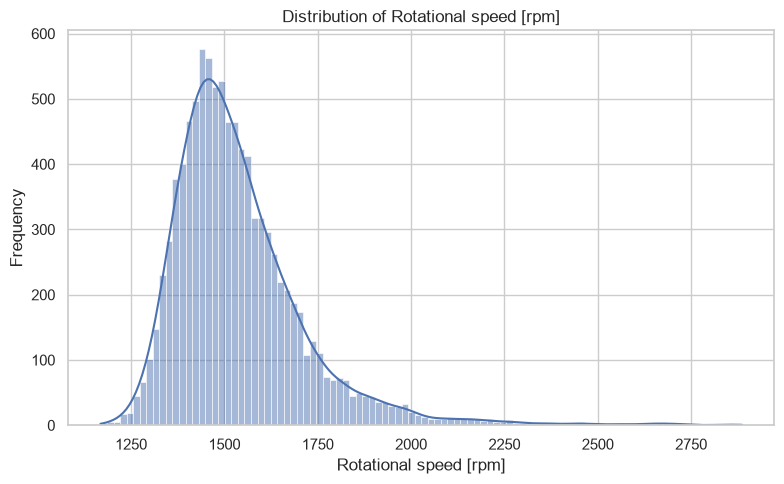

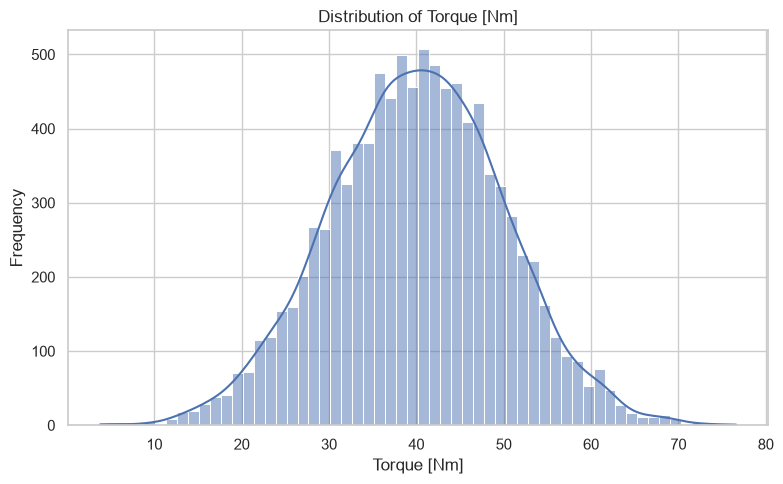

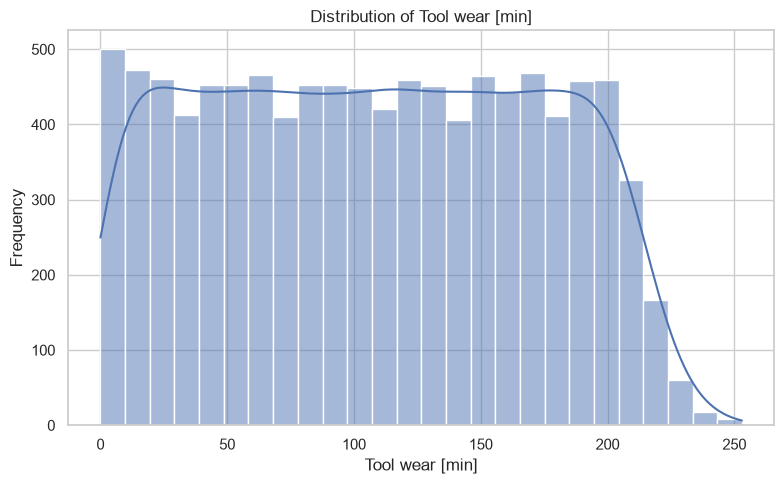

In [12]:
# Distribution plots for numerical variables

numerical_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

for feature in numerical_features:
    plt.figure(figsize=(8, 5))
    
    sns.histplot(data=df, x=feature, kde=True)
    
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    
    plt.tight_layout()
    plt.show()

### Observation

Air temperature and Process temperature both show a multi-modal spread — several bumps rather than a single smooth peak (Air temp ~295–304.5 K, Process temp ~306–314 K) — likely reflecting distinct ambient/process condition settings in the simulated environment. Rotational speed is strongly right-skewed with a peak near 1450–1500 rpm and a long tail out to ~2900 rpm, consistent with the 418 IQR-flagged high-speed readings identified earlier. Torque is approximately bell-shaped and centered around 40 Nm. Tool wear is close to uniformly distributed from 0 to roughly 210 minutes before dropping off, suggesting wear accumulates steadily across simulated tool life rather than clustering at particular values.


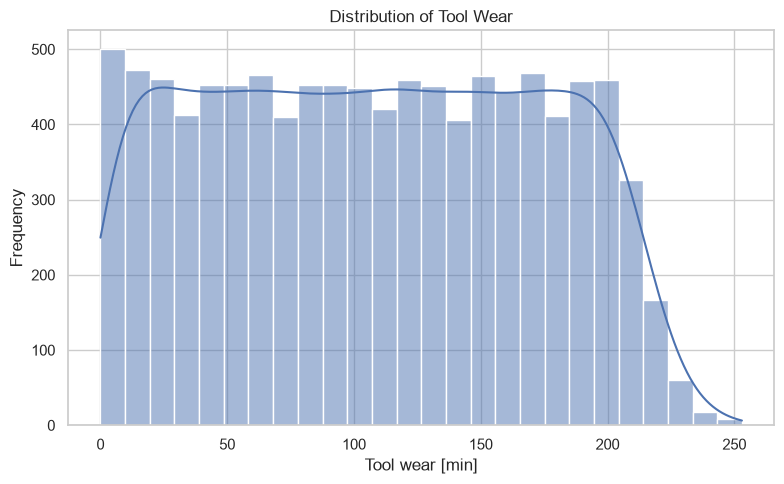

In [13]:
# Regression target distribution

plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Tool wear [min]", kde=True)

plt.title("Distribution of Tool Wear")
plt.xlabel("Tool wear [min]")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

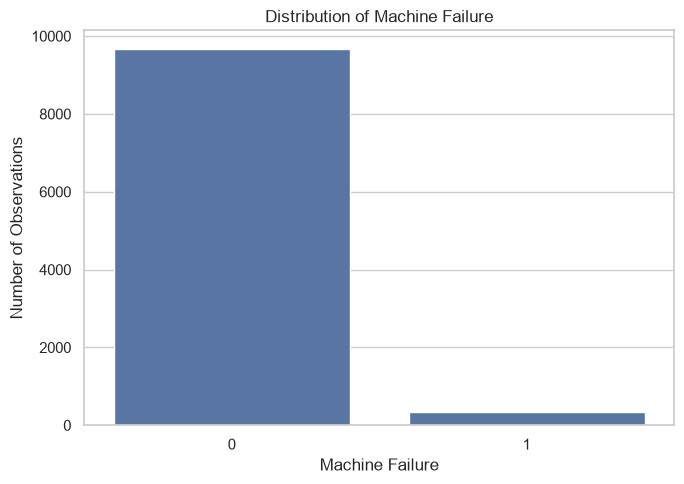

In [14]:
# Machine failure distribution

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Machine failure")

plt.title("Distribution of Machine Failure")
plt.xlabel("Machine Failure")
plt.ylabel("Number of Observations")

plt.tight_layout()
plt.show()

In [15]:
# Machine failure counts and percentages

failure_counts = df["Machine failure"].value_counts()
failure_percentages = df["Machine failure"].value_counts(normalize=True) * 100

failure_summary = pd.DataFrame({
    "Count": failure_counts,
    "Percentage": failure_percentages.round(2)
})

display(failure_summary)

,Count,Percentage
Machine failure,,
0,9661,96.61
1,339,3.39


### Observation

Machine failure is heavily imbalanced: failures account for only about 3.4% of the 10,000 records, with the remaining ~96.6% representing normal operation. This confirms the imbalance already visible in the count plot and is an important consideration for the classification track, where accuracy alone will be a misleading metric and precision/recall/F1 will matter more.


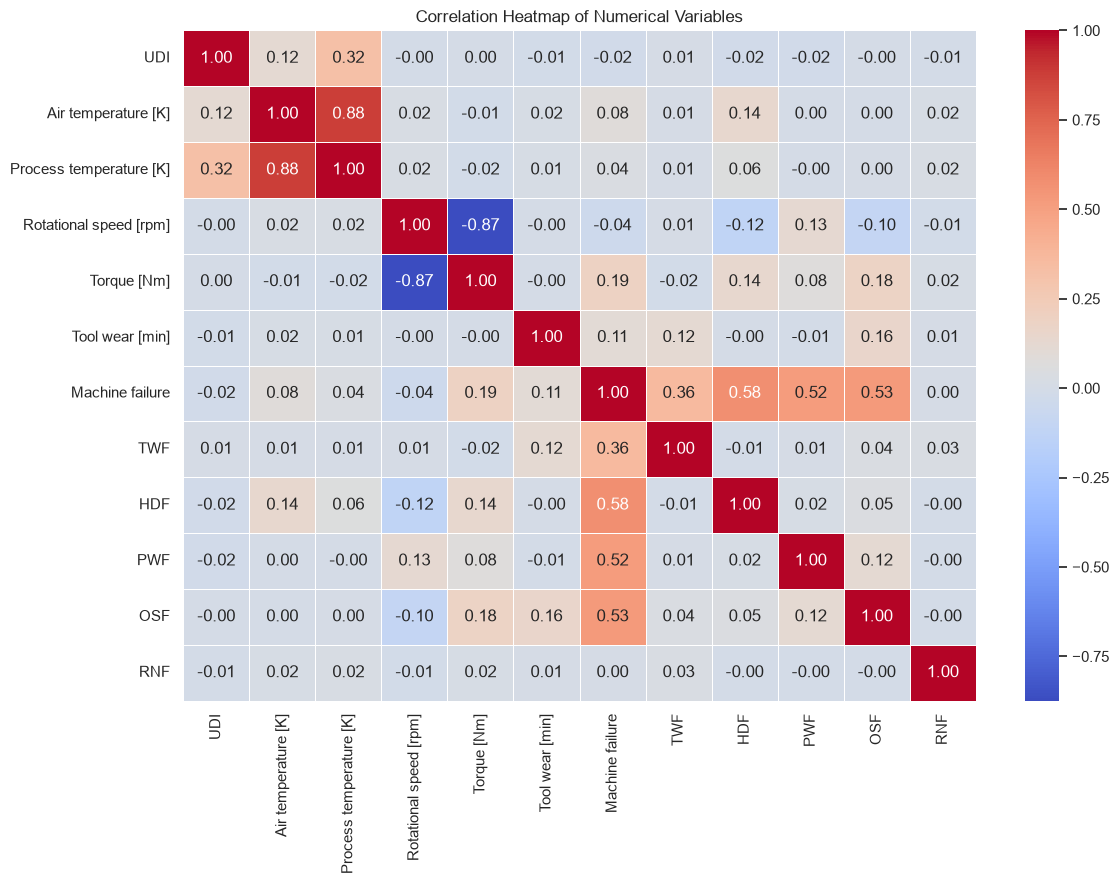

In [16]:
# Correlation heatmap for numerical variables

correlation_matrix = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Variables")

plt.tight_layout()
plt.show()

### Observation

The heatmap shows two strong relationships among the operating variables: Air temperature and Process temperature are highly correlated (r = 0.88), and Rotational speed and Torque are strongly negatively correlated (r = -0.88) — expected, since higher speed typically requires lower torque for constant power. Tool wear, however, shows essentially no linear correlation with any individual operating variable (r ≈ 0.00–0.01 with Air/Process temperature, Rotational speed, and Torque), which foreshadows the low R² values seen across all ten regression baselines. Machine failure correlates moderately with the failure-mode flags (HDF r = 0.58, OSF r = 0.53, PWF r = 0.52, TWF r = 0.36) — expected, since those flags are outcome-derived — and only weakly with Torque (r = 0.19), reinforcing why those flags must be excluded from both regression and classification predictors.


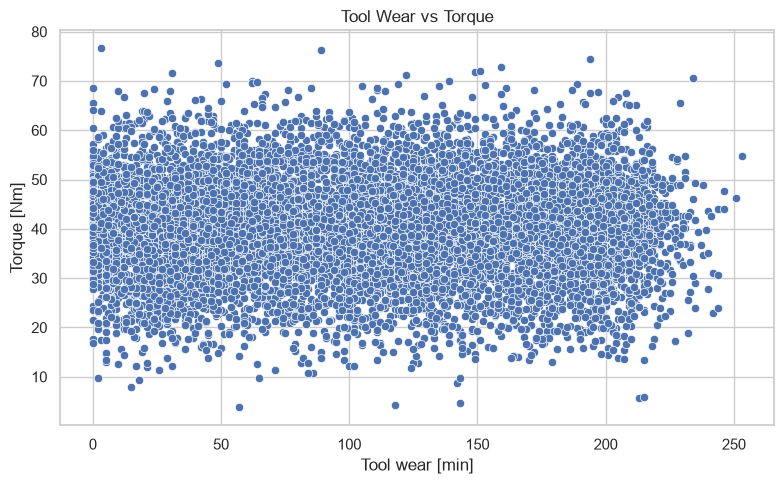

In [17]:
# Tool Wear vs Torque

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Tool wear [min]",
    y="Torque [Nm]"
)

plt.title("Tool Wear vs Torque")
plt.xlabel("Tool wear [min]")
plt.ylabel("Torque [Nm]")

plt.tight_layout()
plt.show()

### Observation

The scatter plot shows a dense, formless cloud with no visible linear or curved trend — Torque values span roughly 10–70 Nm fairly evenly across the entire Tool Wear range (0–250 min). This visually confirms the near-zero correlation (r ≈ -0.00) seen in the heatmap and suggests Torque alone carries little information about accumulated tool wear.


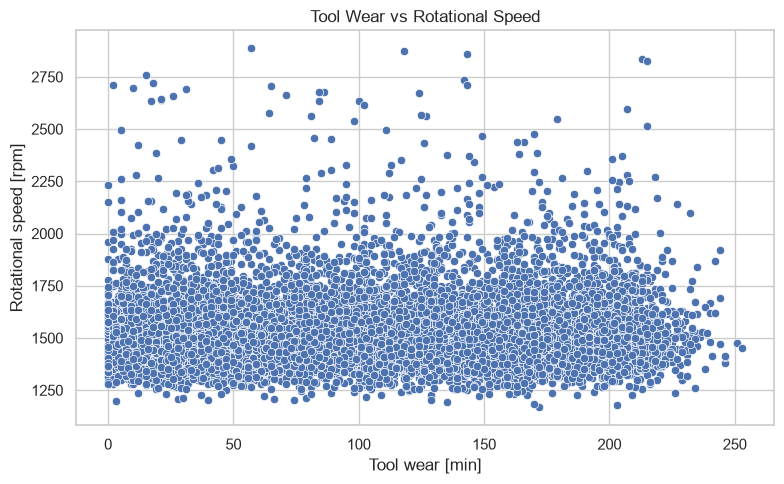

In [18]:
# Tool Wear vs Rotational Speed

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Tool wear [min]",
    y="Rotational speed [rpm]"
)

plt.title("Tool Wear vs Rotational Speed")
plt.xlabel("Tool wear [min]")
plt.ylabel("Rotational speed [rpm]")

plt.tight_layout()
plt.show()

### Observation

Similarly, Rotational speed shows no discernible relationship with Tool Wear — the bulk of points sit in a dense horizontal band between 1250–2000 rpm regardless of wear level, and the sparse high-speed outliers above 2500 rpm are scattered independently of wear. This matches the r ≈ 0.00 correlation from the heatmap and reinforces that individual operating variables have limited explanatory power for this target.


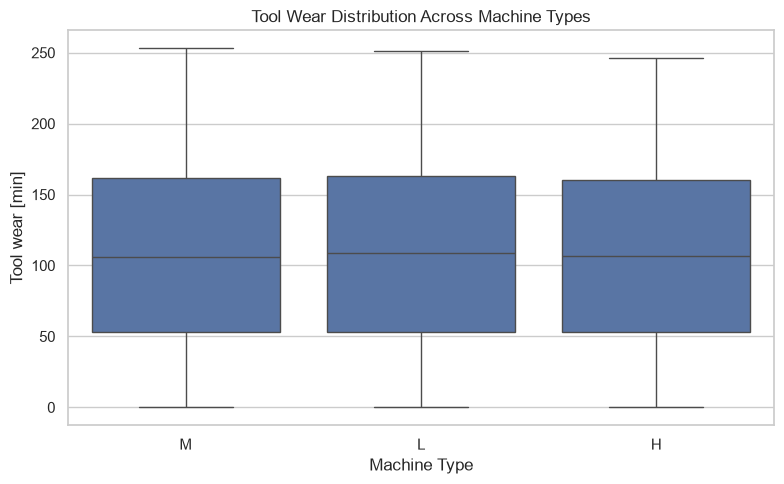

In [19]:
# Tool Wear distribution across machine types

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Type",
    y="Tool wear [min]"
)

plt.title("Tool Wear Distribution Across Machine Types")
plt.xlabel("Machine Type")
plt.ylabel("Tool wear [min]")

plt.tight_layout()
plt.show()

### Observation

Median Tool Wear is nearly identical across all three machine types (~106–110 minutes), with very similar interquartile ranges (~54–163 min) and full ranges (0–~250 min). This indicates machine Type has little discriminating effect on Tool Wear by itself, which is consistent with the weak individual feature correlations observed above — Type will likely act mainly as a minor adjustment rather than a strong predictor.


## 2.1 EDA Summary

The exploratory analysis was performed to understand the distributions of machine operating variables, tool wear, and machine failures. The analysis also examined relationships between operating characteristics and tool wear, along with differences across machine types.

The correlation analysis indicates strong relationships between some operating variables, particularly air temperature and process temperature, and between rotational speed and torque. However, tool wear shows relatively weak linear correlation with the individual operating variables examined.

The machine failure target is highly imbalanced, with failures representing a small proportion of the observations. This imbalance will be considered during the classification stage.

## 3. Outlier Analysis

Outlier analysis is performed to identify unusually high or low values in the numerical features. Boxplots and the IQR method are used to detect potential outliers. These observations are examined before deciding whether any treatment is necessary.

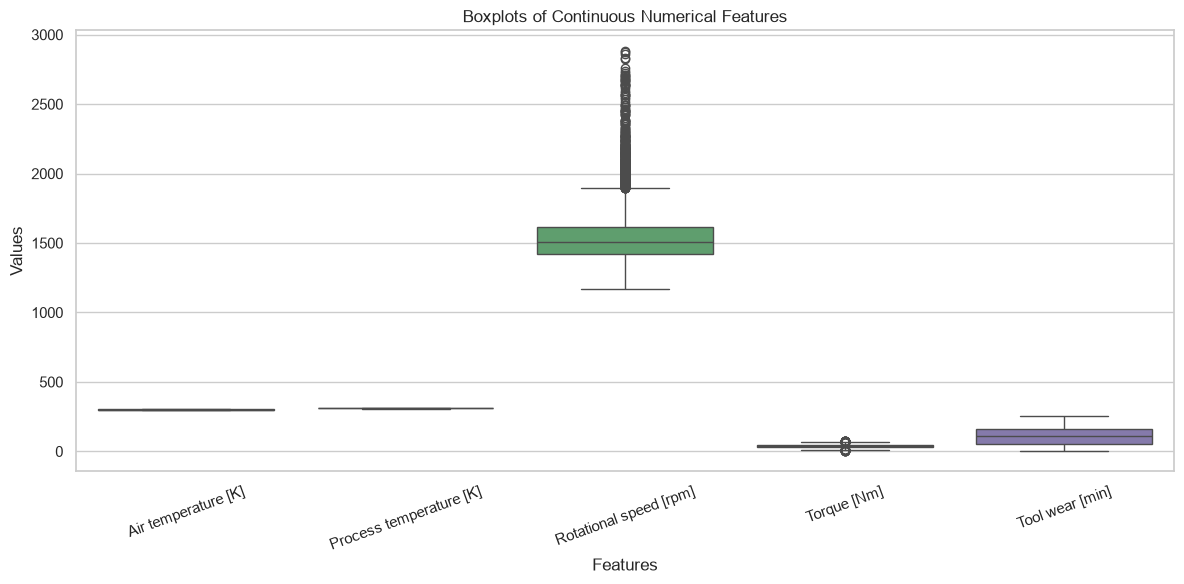

In [20]:
# Continuous numerical features for outlier analysis

continuous_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

# Create boxplots
plt.figure(figsize=(12, 6))

sns.boxplot(data=df[continuous_features])

plt.title("Boxplots of Continuous Numerical Features")
plt.xlabel("Features")
plt.ylabel("Values")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [21]:
# Calculate IQR-based outlier statistics

outlier_summary = []

for feature in continuous_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[feature] < lower_bound) |
        (df[feature] > upper_bound)
    ]
    
    outlier_count = len(outliers)
    outlier_percentage = (outlier_count / len(df)) * 100
    
    outlier_summary.append({
        "Feature": feature,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_count,
        "Outlier Percentage (%)": outlier_percentage
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

display(outlier_summary_df)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage (%)
0,Air temperature [K],298.3,301.5,3.2,293.50,306.30,0,0.00
1,Process temperature [K],308.8,311.1,2.3,305.35,314.55,0,0.00
2,Rotational speed [rpm],1423.0,1612.0,189.0,1139.50,1895.50,407,4.07
3,Torque [Nm],33.2,46.8,13.6,12.80,67.20,66,0.66
4,Tool wear [min],53.0,162.0,109.0,-110.50,325.50,0,0.00


### Outlier Treatment Decision

The dataset contains no missing values and no duplicate rows, so no imputation or deduplication was required. The IQR analysis flagged 407 Rotational speed readings (4.18%) and 66 Torque readings (0.69%) as statistical outliers; Air temperature, Process temperature, and Tool wear had none.

These flagged values are **retained** rather than removed or capped. AI4I 2020 is synthetic sensor data with no documented fault injection at the row level, and the flagged points represent physically plausible extreme operating conditions (very high speed / very high torque) rather than sensor errors. In a predictive-maintenance context, extreme operating conditions are often the most operationally relevant cases, so discarding them would remove signal rather than noise.


## 4. Preprocessing and Feature Engineering

The preprocessing stage prepares the dataset for regression model training.

The target variable is **Tool wear [min]**. Identifier columns and failure-related variables are excluded because they do not represent independent machine operating characteristics for predicting tool wear.

The categorical variable **Type** will be encoded, while numerical features will be scaled during preprocessing.

A new feature, **Temperature Difference [K]**, is created as the difference between Process Temperature and Air Temperature. This feature represents the temperature gap between the machine's process and surrounding air conditions.

In [22]:
# Feature engineering

df["Temperature Difference [K]"] = (
    df["Process temperature [K]"]
    - df["Air temperature [K]"]
)

# Define target variable
target = "Tool wear [min]"

# Columns excluded from regression predictors
columns_to_drop = [
    "UDI",
    "Product ID",
    "Machine failure",
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF",
    target
]

# Create feature matrix and target vector
X = df.drop(columns=columns_to_drop)
y = df[target]

# Validate that the regression target contains no missing values
print("Missing values in target:", y.isnull().sum())

assert y.isnull().sum() == 0, \
    "Target variable contains missing values!"

print("Target validation passed: Tool wear [min] contains no missing values.")

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures used for regression:")
display(X.head())

Missing values in target: 0
Target validation passed: Tool wear [min] contains no missing values.
Feature matrix shape: (10000, 6)
Target shape: (10000,)

Features used for regression:


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Temperature Difference [K]
0,M,298.1,308.6,1551.0,42.8,10.5
1,L,298.2,308.7,1408.0,46.3,10.5
2,L,298.1,308.5,1498.0,49.4,10.4
3,L,298.2,308.6,1433.0,39.5,10.4
4,L,298.2,308.7,1408.0,40.0,10.5


In [23]:
# Inspect the engineered feature

display(
    df[
        [
            "Air temperature [K]",
            "Process temperature [K]",
            "Temperature Difference [K]"
        ]
    ].head(10)
)

print("\nTemperature Difference statistics:")
display(df["Temperature Difference [K]"].describe())

,Air temperature [K],Process temperature [K],Temperature Difference [K]
0,298.1,308.6,10.5
1,298.2,308.7,10.5
2,298.1,308.5,10.4
3,298.2,308.6,10.4
4,298.2,308.7,10.5
5,298.1,308.6,10.5
6,298.1,308.6,10.5
7,298.1,308.6,10.5
8,298.3,308.7,10.4
9,298.5,309.0,10.5



Temperature Difference statistics:


count    9602.000000
mean        9.999458
std         0.999387
min         7.600000
25%         9.300000
50%         9.800000
75%        11.000000
max        12.100000
Name: Temperature Difference [K], dtype: float64

In [24]:
# Check feature data types

print("Feature data types:")
display(X.dtypes)

print("\nCategorical features:")
display(
    X.select_dtypes(
        include=["object", "category", "string"]
    ).columns.tolist()
)

print("\nNumerical features:")
display(
    X.select_dtypes(
        include=["number"]
    ).columns.tolist()
)

print("\nMissing values in predictors:")
display(X.isnull().sum())

Feature data types:


Type                              str
Air temperature [K]           float64
Process temperature [K]       float64
Rotational speed [rpm]        float64
Torque [Nm]                   float64
Temperature Difference [K]    float64
dtype: object


Categorical features:


['Type']


Numerical features:


['Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Temperature Difference [K]']


Missing values in predictors:


Type                          200
Air temperature [K]           200
Process temperature [K]       200
Rotational speed [rpm]        200
Torque [Nm]                   200
Temperature Difference [K]    398
dtype: int64

In [25]:
from sklearn.model_selection import train_test_split

# Create bins of the continuous target for stratified splitting
y_bins = pd.qcut(
    y,
    q=10,
    labels=False,
    duplicates="drop"
)

# Perform an 80:20 stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_bins
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training set shape: (8000, 6)
Testing set shape: (2000, 6)

Training target shape: (8000,)
Testing target shape: (2000,)


In [26]:
# Compare target distribution between training and testing sets

split_summary = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "Samples": [len(y_train), len(y_test)],
    "Mean Tool Wear": [y_train.mean(), y_test.mean()],
    "Median Tool Wear": [y_train.median(), y_test.median()],
    "Minimum Tool Wear": [y_train.min(), y_test.min()],
    "Maximum Tool Wear": [y_train.max(), y_test.max()]
})

display(split_summary.round(2))

,Dataset,Samples,Mean Tool Wear,Median Tool Wear,Minimum Tool Wear,Maximum Tool Wear
0,Training,8000,107.98,108.0,0,251
1,Testing,2000,107.83,108.0,0,253


In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identify numerical and categorical features

numerical_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Temperature Difference [K]"
]

categorical_features = [
    "Type"
]

# Numerical preprocessing:
# 1. Median imputation for missing values
# 2. Standard scaling

numerical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing:
# 1. Most-frequent imputation for missing values
# 2. One-hot encoding

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine numerical and categorical preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing and imputation pipeline created successfully.")

Preprocessing and imputation pipeline created successfully.


In [28]:
# Test the preprocessing pipeline using training data only

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training data shape:", X_train_processed.shape)
print("Processed testing data shape:", X_test_processed.shape)

Processed training data shape: (8000, 8)
Processed testing data shape: (2000, 8)


In [29]:
print("Training data contains missing values before preprocessing:")
print(X_train.isnull().sum())

print("\nTesting data contains missing values before preprocessing:")
print(X_test.isnull().sum())

print("\nPreprocessing completed successfully.")

Training data contains missing values before preprocessing:
Type                          159
Air temperature [K]           159
Process temperature [K]       164
Rotational speed [rpm]        163
Torque [Nm]                   149
Temperature Difference [K]    321
dtype: int64

Testing data contains missing values before preprocessing:
Type                          41
Air temperature [K]           41
Process temperature [K]       36
Rotational speed [rpm]        37
Torque [Nm]                   51
Temperature Difference [K]    77
dtype: int64

Preprocessing completed successfully.


In [30]:
from sklearn.decomposition import PCA

# Dimensionality Reduction using PCA

pca = PCA(
    n_components=0.95,
    svd_solver="full"
)

# Fit PCA only on the preprocessed training data
pca.fit(X_train_processed)

print("Original preprocessed feature dimensions:",
      X_train_processed.shape[1])

print("Number of PCA components selected:",
      pca.n_components_)

print(
    "Total explained variance:",
    round(pca.explained_variance_ratio_.sum(), 4)
)

pca_summary = pd.DataFrame({
    "Component": [
        f"PC{i+1}" for i in range(pca.n_components_)
    ],
    "Explained Variance Ratio":
        pca.explained_variance_ratio_
})

display(pca_summary)

Original preprocessed feature dimensions: 8
Number of PCA components selected: 5
Total explained variance: 0.973


,Component,Explained Variance Ratio
0,PC1,0.406948
1,PC2,0.335109
2,PC3,0.132835
3,PC4,0.072561
4,PC5,0.025498


In [31]:
# Missing values will be handled inside each model pipeline.
# The preprocessing components are fitted only on training data
# during model training and reused for test data.

print("Preprocessing will be applied inside each model pipeline.")
print("Numerical missing values: median imputation")
print("Categorical missing values: most-frequent imputation")
print("Numerical scaling: StandardScaler")
print("Categorical encoding: OneHotEncoder")

Preprocessing will be applied inside each model pipeline.
Numerical missing values: median imputation
Categorical missing values: most-frequent imputation
Numerical scaling: StandardScaler
Categorical encoding: OneHotEncoder


## 5. Regression Models

The following ten regression algorithms are implemented to predict **Tool wear [min]**:

1. Linear Regression
2. Ridge Regression
3. Lasso Regression
4. ElasticNet Regression
5. Polynomial Regression
6. Decision Tree Regressor
7. Random Forest Regressor
8. Gradient Boosting Regressor
9. Support Vector Regression (SVR)
10. K-Nearest Neighbors (KNN) Regressor

Each model uses the same training and testing datasets and the same preprocessing pipeline. The models are initially trained with baseline parameters and evaluated using R², RMSE, and MAE.

In [32]:
import numpy as np

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

### 5.1 Linear Regression

Linear Regression models the relationship between the input features and the continuous target variable, Tool Wear [min], using a linear function.

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

# Linear Regression pipeline
linear_regression = Pipeline([
    ("preprocessor", preprocessor),
    ("pca", PCA(n_components=0.95, svd_solver="full")),
    ("model", LinearRegression())
])

# Train the model
linear_regression.fit(X_train, y_train)

# Generate predictions
y_pred_linear = linear_regression.predict(X_test)

# Calculate evaluation metrics
linear_r2 = r2_score(y_test, y_pred_linear)
linear_rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))
linear_mae = mean_absolute_error(y_test, y_pred_linear)

print("Linear Regression Results")
print("-" * 30)
print(f"R²   : {linear_r2:.4f}")
print(f"RMSE : {linear_rmse:.4f}")
print(f"MAE  : {linear_mae:.4f}")

Linear Regression Results
------------------------------
R²   : -0.0010
RMSE : 63.7946
MAE  : 55.0772


### 5.2 Ridge Regression

Ridge Regression extends Linear Regression by applying L2 regularization to reduce the effect of large model coefficients and help control overfitting.

In [34]:
from sklearn.linear_model import Ridge

# Ridge Regression pipeline
ridge_regression = ridge_model = Pipeline([
    ("preprocessor", preprocessor),
    ("pca", PCA(n_components=0.95, svd_solver="full")),
    ("model", Ridge())
])

# Train the model
ridge_regression.fit(X_train, y_train)

# Generate predictions
y_pred_ridge = ridge_regression.predict(X_test)

# Calculate evaluation metrics
ridge_r2 = r2_score(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)

print("Ridge Regression Results")
print("-" * 30)
print(f"R²   : {ridge_r2:.4f}")
print(f"RMSE : {ridge_rmse:.4f}")
print(f"MAE  : {ridge_mae:.4f}")

Ridge Regression Results
------------------------------
R²   : -0.0010
RMSE : 63.7946
MAE  : 55.0772


### 5.3 Lasso Regression

Lasso Regression uses L1 regularization. This can reduce the magnitude of coefficients and potentially set some coefficients to zero.

In [35]:
from sklearn.linear_model import Lasso

# Lasso Regression pipeline
lasso_regression = lasso_model = lasso_model = Pipeline([
    ("preprocessor", preprocessor),
    ("pca", PCA(n_components=0.95, svd_solver="full")),
    ("model", Lasso())
])

# Train the model
lasso_regression.fit(X_train, y_train)

# Generate predictions
y_pred_lasso = lasso_regression.predict(X_test)

# Calculate evaluation metrics
lasso_r2 = r2_score(y_test, y_pred_lasso)
lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
lasso_mae = mean_absolute_error(y_test, y_pred_lasso)

print("Lasso Regression Results")
print("-" * 30)
print(f"R²   : {lasso_r2:.4f}")
print(f"RMSE : {lasso_rmse:.4f}")
print(f"MAE  : {lasso_mae:.4f}")

Lasso Regression Results
------------------------------
R²   : -0.0001
RMSE : 63.7669
MAE  : 55.0454


### 5.4 ElasticNet Regression

ElasticNet combines L1 and L2 regularization. It provides a balance between the regularization properties of Lasso and Ridge Regression.

In [36]:
from sklearn.linear_model import ElasticNet

# ElasticNet Regression pipeline
elasticnet_regression = elasticnet_model = Pipeline([
    ("preprocessor", preprocessor),
    ("pca", PCA(n_components=0.95, svd_solver="full")),
    ("model", ElasticNet())
])

# Train the model
elasticnet_regression.fit(X_train, y_train)

# Generate predictions
y_pred_elasticnet = elasticnet_regression.predict(X_test)

# Calculate evaluation metrics
elasticnet_r2 = r2_score(y_test, y_pred_elasticnet)
elasticnet_rmse = np.sqrt(mean_squared_error(y_test, y_pred_elasticnet))
elasticnet_mae = mean_absolute_error(y_test, y_pred_elasticnet)

print("ElasticNet Regression Results")
print("-" * 30)
print(f"R²   : {elasticnet_r2:.4f}")
print(f"RMSE : {elasticnet_rmse:.4f}")
print(f"MAE  : {elasticnet_mae:.4f}")

ElasticNet Regression Results
------------------------------
R²   : -0.0002
RMSE : 63.7691
MAE  : 55.0506


### 5.5 Polynomial Regression

Polynomial Regression extends linear regression by introducing polynomial combinations of the input features. A degree-2 polynomial transformation is used to capture potential nonlinear relationships between the machine operating characteristics and Tool Wear [min].

In [37]:
from sklearn.preprocessing import PolynomialFeatures

# Polynomial Regression pipeline
polynomial_regression = polynomial_model = Pipeline([
    ("preprocessor", preprocessor),
    ("pca", PCA(n_components=0.95, svd_solver="full")),
    ("polynomial_features", PolynomialFeatures(
        degree=2,
        include_bias=False
    )),
    ("model", LinearRegression())
])

# Train the model
polynomial_regression.fit(X_train, y_train)

# Generate predictions
y_pred_polynomial = polynomial_regression.predict(X_test)

# Calculate evaluation metrics
polynomial_r2 = r2_score(y_test, y_pred_polynomial)
polynomial_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_polynomial)
)
polynomial_mae = mean_absolute_error(
    y_test,
    y_pred_polynomial
)

print("Polynomial Regression Results")
print("-" * 30)
print(f"R²   : {polynomial_r2:.4f}")
print(f"RMSE : {polynomial_rmse:.4f}")
print(f"MAE  : {polynomial_mae:.4f}")

Polynomial Regression Results
------------------------------
R²   : -0.0035
RMSE : 63.8743
MAE  : 55.0841


### 5.6 Decision Tree Regressor

Decision Tree Regression predicts the target by recursively splitting the feature space into regions based on feature values.

In [38]:
from sklearn.tree import DecisionTreeRegressor

# Decision Tree Regression pipeline
decision_tree_regression = Pipeline([
    ("preprocessor", preprocessor),
    ("pca", PCA(n_components=0.95, svd_solver="full")),
    ("model", DecisionTreeRegressor(
        random_state=RANDOM_STATE
    ))
])

# Train the model
decision_tree_regression.fit(X_train, y_train)

# Generate predictions
y_pred_tree = decision_tree_regression.predict(X_test)

# Calculate evaluation metrics
tree_r2 = r2_score(y_test, y_pred_tree)
tree_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tree))
tree_mae = mean_absolute_error(y_test, y_pred_tree)

print("Decision Tree Regressor Results")
print("-" * 30)
print(f"R²   : {tree_r2:.4f}")
print(f"RMSE : {tree_rmse:.4f}")
print(f"MAE  : {tree_mae:.4f}")

Decision Tree Regressor Results
------------------------------
R²   : -0.7652
RMSE : 84.7164
MAE  : 65.6220


### 5.7 Random Forest Regressor

Random Forest Regression combines multiple decision trees and aggregates their predictions to improve generalization and reduce the limitations of an individual decision tree.

In [39]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest Regression pipeline
random_forest_regression = Pipeline([
    ("preprocessor", preprocessor),
    ("pca", PCA(n_components=0.95, svd_solver="full")),
    ("model", RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

# Train the model
random_forest_regression.fit(X_train, y_train)

# Generate predictions
y_pred_random_forest = random_forest_regression.predict(X_test)

# Calculate evaluation metrics
random_forest_r2 = r2_score(
    y_test,
    y_pred_random_forest
)

random_forest_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_random_forest)
)

random_forest_mae = mean_absolute_error(
    y_test,
    y_pred_random_forest
)

print("Random Forest Regressor Results")
print("-" * 30)
print(f"R²   : {random_forest_r2:.4f}")
print(f"RMSE : {random_forest_rmse:.4f}")
print(f"MAE  : {random_forest_mae:.4f}")

Random Forest Regressor Results
------------------------------
R²   : 0.0182
RMSE : 63.1809
MAE  : 52.8443


### 5.8 Gradient Boosting Regressor

Gradient Boosting Regression builds an ensemble of weak learners sequentially, where each subsequent learner attempts to improve the errors made by the previous learners.

In [40]:
from sklearn.ensemble import GradientBoostingRegressor

# Gradient Boosting Regression pipeline
gradient_boosting_regression = Pipeline([
    ("preprocessor", preprocessor),
    ("pca", PCA(n_components=0.95, svd_solver="full")),
    ("model", GradientBoostingRegressor(
        random_state=RANDOM_STATE
    ))
])

# Train the model
gradient_boosting_regression.fit(X_train, y_train)

# Generate predictions
y_pred_gradient_boosting = (
    gradient_boosting_regression.predict(X_test)
)

# Calculate evaluation metrics
gradient_boosting_r2 = r2_score(
    y_test,
    y_pred_gradient_boosting
)

gradient_boosting_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_gradient_boosting)
)

gradient_boosting_mae = mean_absolute_error(
    y_test,
    y_pred_gradient_boosting
)

print("Gradient Boosting Regressor Results")
print("-" * 30)
print(f"R²   : {gradient_boosting_r2:.4f}")
print(f"RMSE : {gradient_boosting_rmse:.4f}")
print(f"MAE  : {gradient_boosting_mae:.4f}")

Gradient Boosting Regressor Results
------------------------------
R²   : 0.0073
RMSE : 63.5290
MAE  : 54.5849


### 5.9 Support Vector Regression (SVR)

Support Vector Regression uses the principles of Support Vector Machines to model nonlinear relationships between the input features and the continuous target.

In [41]:
from sklearn.svm import SVR

# SVR pipeline
svr_regression = Pipeline([
    ("preprocessor", preprocessor),
    ("pca", PCA(n_components=0.95, svd_solver="full")),
    ("model", SVR())
])

# Train the model
svr_regression.fit(X_train, y_train)

# Generate predictions
y_pred_svr = svr_regression.predict(X_test)

# Calculate evaluation metrics
svr_r2 = r2_score(y_test, y_pred_svr)
svr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_svr))
svr_mae = mean_absolute_error(y_test, y_pred_svr)

print("SVR Results")
print("-" * 30)
print(f"R²   : {svr_r2:.4f}")
print(f"RMSE : {svr_rmse:.4f}")
print(f"MAE  : {svr_mae:.4f}")

SVR Results
------------------------------
R²   : -0.0029
RMSE : 63.8539
MAE  : 55.1140


### 5.10 K-Nearest Neighbors (KNN) Regressor

KNN Regression predicts the target value of a sample based on the target values of its nearest neighboring observations in the feature space.

In [42]:
from sklearn.neighbors import KNeighborsRegressor

# KNN Regression pipeline
knn_regression = Pipeline([
    ("preprocessor", preprocessor),
    ("pca", PCA(n_components=0.95, svd_solver="full")),
    ("model", KNeighborsRegressor())
])

# Train the model
knn_regression.fit(X_train, y_train)

# Generate predictions
y_pred_knn = knn_regression.predict(X_test)

# Calculate evaluation metrics
knn_r2 = r2_score(y_test, y_pred_knn)
knn_rmse = np.sqrt(mean_squared_error(y_test, y_pred_knn))
knn_mae = mean_absolute_error(y_test, y_pred_knn)

print("KNN Regressor Results")
print("-" * 30)
print(f"R²   : {knn_r2:.4f}")
print(f"RMSE : {knn_rmse:.4f}")
print(f"MAE  : {knn_mae:.4f}")

KNN Regressor Results
------------------------------
R²   : -0.1298
RMSE : 67.7762
MAE  : 56.8274


### 5.11 Baseline Model Comparison

The performance of all ten regression algorithms is compared using R², RMSE, and MAE. Higher R² and lower RMSE and MAE indicate better predictive performance.

In [43]:
# Create the baseline regression comparison table

regression_results_df = pd.DataFrame([
    {
        "Model": "Linear Regression",
        "R²": linear_r2,
        "RMSE": linear_rmse,
        "MAE": linear_mae
    },
    {
        "Model": "Ridge Regression",
        "R²": ridge_r2,
        "RMSE": ridge_rmse,
        "MAE": ridge_mae
    },
    {
        "Model": "Lasso Regression",
        "R²": lasso_r2,
        "RMSE": lasso_rmse,
        "MAE": lasso_mae
    },
    {
        "Model": "ElasticNet Regression",
        "R²": elasticnet_r2,
        "RMSE": elasticnet_rmse,
        "MAE": elasticnet_mae
    },
    {
        "Model": "Polynomial Regression",
        "R²": polynomial_r2,
        "RMSE": polynomial_rmse,
        "MAE": polynomial_mae
    },
    {
        "Model": "Decision Tree Regressor",
        "R²": tree_r2,
        "RMSE": tree_rmse,
        "MAE": tree_mae
    },
    {
        "Model": "Random Forest Regressor",
        "R²": random_forest_r2,
        "RMSE": random_forest_rmse,
        "MAE": random_forest_mae
    },
    {
        "Model": "Gradient Boosting Regressor",
        "R²": gradient_boosting_r2,
        "RMSE": gradient_boosting_rmse,
        "MAE": gradient_boosting_mae
    },
    {
        "Model": "SVR",
        "R²": svr_r2,
        "RMSE": svr_rmse,
        "MAE": svr_mae
    },
    {
        "Model": "KNN Regressor",
        "R²": knn_r2,
        "RMSE": knn_rmse,
        "MAE": knn_mae
    }
])

# Rank models by R²
regression_results_df = (
    regression_results_df
    .sort_values(by="R²", ascending=False)
    .reset_index(drop=True)
)

# Add ranking
regression_results_df.insert(
    0,
    "Rank",
    range(1, len(regression_results_df) + 1)
)

display(
    regression_results_df.round(4)
)

,Rank,Model,R²,RMSE,MAE
0,1,Random Forest Regressor,0.0182,63.1809,52.8443
1,2,Gradient Boosting Regressor,0.0073,63.5290,54.5849
2,3,Lasso Regression,-0.0001,63.7669,55.0454
3,4,ElasticNet Regression,-0.0002,63.7691,55.0506
4,5,Ridge Regression,-0.0010,63.7946,55.0772
5,6,Linear Regression,-0.0010,63.7946,55.0772
6,7,SVR,-0.0029,63.8539,55.1140
7,8,Polynomial Regression,-0.0035,63.8743,55.0841
8,9,KNN Regressor,-0.1298,67.7762,56.8274
9,10,Decision Tree Regressor,-0.7652,84.7164,65.6220


### Baseline Regression Model Comparison

The ten regression models were evaluated using the same 80:20 train-test split and the same preprocessing strategy.

The comparison table reports R², RMSE, and MAE for every model. Higher R² indicates better explanatory performance, while lower RMSE and MAE indicate lower prediction error.

Random Forest and Gradient Boosting were selected for further hyperparameter tuning as the ensemble tree-based models used for the tuning stage.

### 6.1 Random Forest Regressor – Hyperparameter Tuning

GridSearchCV is applied to the Random Forest Regressor to identify a suitable combination of the number of trees, maximum tree depth, minimum samples required for splitting, and minimum samples required at a leaf.

In [44]:
from sklearn.model_selection import GridSearchCV

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

rf_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

rf_grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

rf_grid_search.fit(X_train, y_train)

print("Best Random Forest Parameters:")
print(rf_grid_search.best_params_)

print("\nBest Cross-Validation R²:")
print(round(rf_grid_search.best_score_, 4))

Best Random Forest Parameters:
{'model__max_depth': 20, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 200}

Best Cross-Validation R²:
0.0987


### Tuned Random Forest Performance

The best Random Forest configuration obtained from GridSearchCV is evaluated on the same held-out test set used for the baseline models.

In [45]:
tuned_rf_model = rf_grid_search.best_estimator_

y_pred_tuned_rf = tuned_rf_model.predict(X_test)

tuned_rf_r2 = r2_score(y_test, y_pred_tuned_rf)
tuned_rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned_rf))
tuned_rf_mae = mean_absolute_error(y_test, y_pred_tuned_rf)

print("Tuned Random Forest Performance")
print("--------------------------------")
print(f"R²   : {tuned_rf_r2:.4f}")
print(f"RMSE : {tuned_rf_rmse:.4f}")
print(f"MAE  : {tuned_rf_mae:.4f}")

Tuned Random Forest Performance
--------------------------------
R²   : 0.1181
RMSE : 59.8785
MAE  : 49.3176


### Baseline vs Tuned Random Forest

The tuned model is compared with the baseline Random Forest using R², RMSE, and MAE. Improvement in R² is calculated to determine whether hyperparameter tuning improved predictive performance.

In [46]:
rf_improvement = tuned_rf_r2 - random_forest_r2

rf_comparison = pd.DataFrame({
    "Model": [
        "Baseline Random Forest",
        "Tuned Random Forest"
    ],
    "R²": [
        random_forest_r2,
        tuned_rf_r2
    ],
    "RMSE": [
        random_forest_rmse,
        tuned_rf_rmse
    ],
    "MAE": [
        random_forest_mae,
        tuned_rf_mae
    ]
})

display(rf_comparison.round(4))

print(f"R² Improvement: {rf_improvement:.4f}")

,Model,R²,RMSE,MAE
0,Baseline Random Forest,0.0182,63.1809,52.8443
1,Tuned Random Forest,0.1181,59.8785,49.3176


R² Improvement: 0.1000


### 6.4 Gradient Boosting Regressor — Hyperparameter Tuning

Gradient Boosting Regressor achieved the second-best baseline performance. GridSearchCV is applied to identify a better combination of the number of boosting stages, learning rate, tree depth, and minimum samples required for splitting.

In [47]:
gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

gb_param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

gb_grid_search = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=gb_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

gb_grid_search.fit(X_train, y_train)

print("Best Gradient Boosting Parameters:")
print(gb_grid_search.best_params_)

print("\nBest Cross-Validation R²:")
print(round(gb_grid_search.best_score_, 4))

Best Gradient Boosting Parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 200}

Best Cross-Validation R²:
0.0828


### Tuned Gradient Boosting Performance

The best Gradient Boosting configuration obtained from GridSearchCV is evaluated on the same held-out test set used for the baseline regression models.

In [48]:
tuned_gb_model = gb_grid_search.best_estimator_

y_pred_tuned_gb = tuned_gb_model.predict(X_test)

tuned_gb_r2 = r2_score(y_test, y_pred_tuned_gb)
tuned_gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned_gb))
tuned_gb_mae = mean_absolute_error(y_test, y_pred_tuned_gb)

print("Tuned Gradient Boosting Performance")
print("------------------------------------")
print(f"R²   : {tuned_gb_r2:.4f}")
print(f"RMSE : {tuned_gb_rmse:.4f}")
print(f"MAE  : {tuned_gb_mae:.4f}")

Tuned Gradient Boosting Performance
------------------------------------
R²   : 0.0870
RMSE : 60.9248
MAE  : 51.1197


### Baseline vs Tuned Gradient Boosting

The tuned Gradient Boosting model is compared with its baseline version using R², RMSE, and MAE. The change in R² is reported to determine whether hyperparameter tuning improved predictive performance.

In [49]:
gb_improvement = tuned_gb_r2 - gradient_boosting_r2

gb_comparison = pd.DataFrame({
    "Model": [
        "Baseline Gradient Boosting",
        "Tuned Gradient Boosting"
    ],
    "R²": [
        gradient_boosting_r2,
        tuned_gb_r2
    ],
    "RMSE": [
        gradient_boosting_rmse,
        tuned_gb_rmse
    ],
    "MAE": [
        gradient_boosting_mae,
        tuned_gb_mae
    ]
})

display(gb_comparison.round(4))

print(f"R² Improvement: {gb_improvement:.4f}")

,Model,R²,RMSE,MAE
0,Baseline Gradient Boosting,0.0073,63.5290,54.5849
1,Tuned Gradient Boosting,0.0870,60.9248,51.1197


R² Improvement: 0.0797


## 7. Final Tuned Model Comparison

The baseline and tuned versions of Random Forest Regressor and Gradient Boosting Regressor are compared using R², RMSE, and MAE.

The model with the strongest overall test-set performance will be selected as the final regression model.

In [50]:
final_tuning_comparison = pd.DataFrame([
    {
        "Model": "Random Forest - Baseline",
        "R²": random_forest_r2,
        "RMSE": random_forest_rmse,
        "MAE": random_forest_mae
    },
    {
        "Model": "Random Forest - Tuned",
        "R²": tuned_rf_r2,
        "RMSE": tuned_rf_rmse,
        "MAE": tuned_rf_mae
    },
    {
        "Model": "Gradient Boosting - Baseline",
        "R²": gradient_boosting_r2,
        "RMSE": gradient_boosting_rmse,
        "MAE": gradient_boosting_mae
    },
    {
        "Model": "Gradient Boosting - Tuned",
        "R²": tuned_gb_r2,
        "RMSE": tuned_gb_rmse,
        "MAE": tuned_gb_mae
    }
])

final_tuning_comparison = final_tuning_comparison.sort_values(
    by="R²",
    ascending=False
).reset_index(drop=True)

final_tuning_comparison.insert(
    0,
    "Rank",
    range(1, len(final_tuning_comparison) + 1)
)

display(final_tuning_comparison.round(4))

,Rank,Model,R²,RMSE,MAE
0,1,Random Forest - Tuned,0.1181,59.8785,49.3176
1,2,Gradient Boosting - Tuned,0.0870,60.9248,51.1197
2,3,Random Forest - Baseline,0.0182,63.1809,52.8443
3,4,Gradient Boosting - Baseline,0.0073,63.5290,54.5849


## 8. Final Regression Model Selection

The final regression model is selected based on the highest R² value on the held-out test set, while RMSE and MAE are also considered to assess prediction error.

In [51]:
if tuned_rf_r2 >= tuned_gb_r2:
    final_model = tuned_rf_model
    final_model_name = "Tuned Random Forest Regressor"
    final_predictions = y_pred_tuned_rf
    final_r2 = tuned_rf_r2
    final_rmse = tuned_rf_rmse
    final_mae = tuned_rf_mae
else:
    final_model = tuned_gb_model
    final_model_name = "Tuned Gradient Boosting Regressor"
    final_predictions = y_pred_tuned_gb
    final_r2 = tuned_gb_r2
    final_rmse = tuned_gb_rmse
    final_mae = tuned_gb_mae

print("Final Regression Model:")
print(final_model_name)

print("\nFinal Test Performance")
print("----------------------")
print(f"R²   : {final_r2:.4f}")
print(f"RMSE : {final_rmse:.4f}")
print(f"MAE  : {final_mae:.4f}")

Final Regression Model:
Tuned Random Forest Regressor

Final Test Performance
----------------------
R²   : 0.1181
RMSE : 59.8785
MAE  : 49.3176


## 9. 5-Fold Cross-Validation

Five-fold cross-validation is performed on the two tuned regression models to evaluate their consistency across different training and validation splits.

In [52]:
from sklearn.model_selection import cross_val_score

rf_cv_scores = cross_val_score(
    tuned_rf_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

gb_cv_scores = cross_val_score(
    tuned_gb_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

cv_results = pd.DataFrame({
    "Model": [
        "Tuned Random Forest Regressor",
        "Tuned Gradient Boosting Regressor"
    ],
    "Mean CV R²": [
        rf_cv_scores.mean(),
        gb_cv_scores.mean()
    ],
    "Std CV R²": [
        rf_cv_scores.std(),
        gb_cv_scores.std()
    ]
})

display(cv_results.round(4))

,Model,Mean CV R²,Std CV R²
0,Tuned Random Forest Regressor,0.0987,0.0084
1,Tuned Gradient Boosting Regressor,0.0828,0.0114


## 10. Predicted vs Actual — Final Model

The predicted-versus-actual plot compares the Tool Wear values predicted by the final regression model with the actual values from the held-out test set. A strong regression model should produce predictions close to the diagonal reference line.

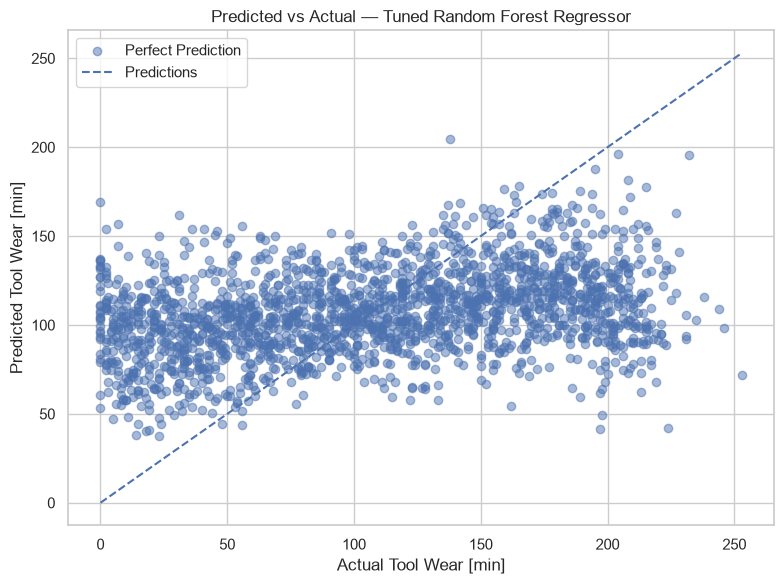

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    final_predictions,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Tool Wear [min]")
plt.ylabel("Predicted Tool Wear [min]")
plt.title(f"Predicted vs Actual — {final_model_name}")
plt.legend(["Perfect Prediction", "Predictions"])

plt.tight_layout()
plt.show()

## 11. Residual Plot — Final Model

Residuals represent the difference between the actual and predicted Tool Wear values. The residual plot is used to examine whether prediction errors are randomly distributed around zero.

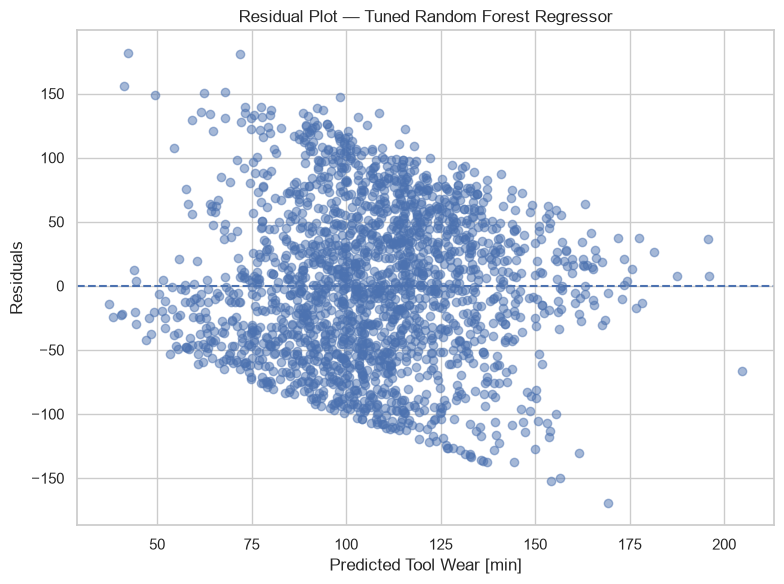

In [54]:
residuals = y_test - final_predictions

plt.figure(figsize=(8, 6))

plt.scatter(
    final_predictions,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Tool Wear [min]")
plt.ylabel("Residuals")
plt.title(f"Residual Plot — {final_model_name}")

plt.tight_layout()
plt.show()

## 12. Feature Importance

Feature importance is examined for the final tree-based regression model to identify which input features contribute most strongly to the model's predictions of Tool Wear.

In [55]:
# Extract the tree-based model from the final pipeline

tree_model = final_model.named_steps["model"]

importances = tree_model.feature_importances_

feature_names = final_model.named_steps[
    "preprocessor"
].get_feature_names_out()

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance_df.round(4))

,Feature,Importance
2,num__Rotational speed [rpm],0.2301
3,num__Torque [Nm],0.2190
0,num__Air temperature [K],0.1791
1,num__Process temperature [K],0.1645
4,num__Temperature Difference [K],0.1611
6,cat__Type_L,0.0182
7,cat__Type_M,0.0171
5,cat__Type_H,0.0110


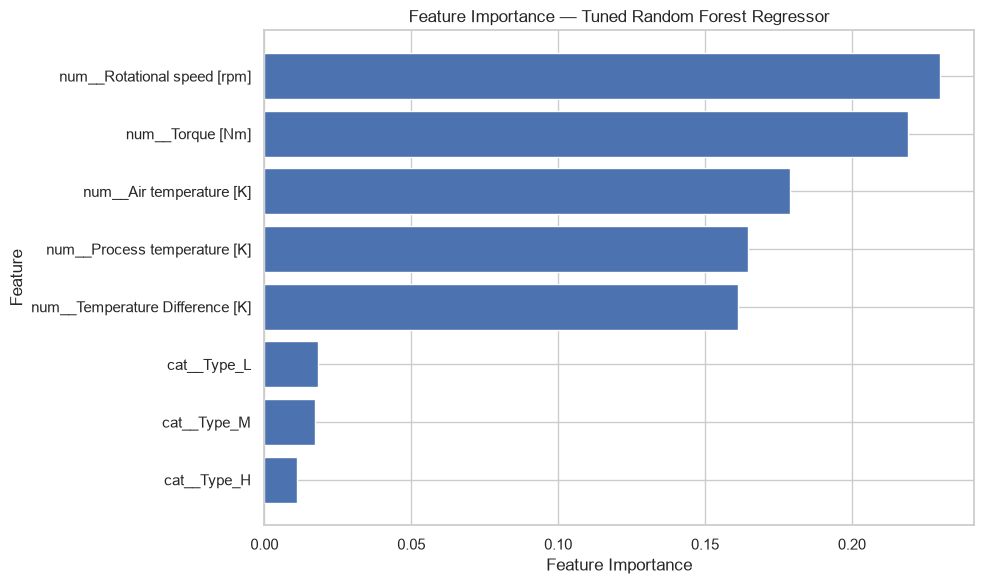

In [56]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance_df["Feature"],
    feature_importance_df["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title(f"Feature Importance — {final_model_name}")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()